In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv")

# DataSet Analysis

## Sanity Check

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


### Data Info Analysis
The output shows that the dataset contains 545 rows for 13 features. 
All the 13 features have 545 non-null values. This indicates that there are no missing entries in any column, this means there is no need for dropping or imputation of any row or columns due to missing values.

## Correlation Matrix

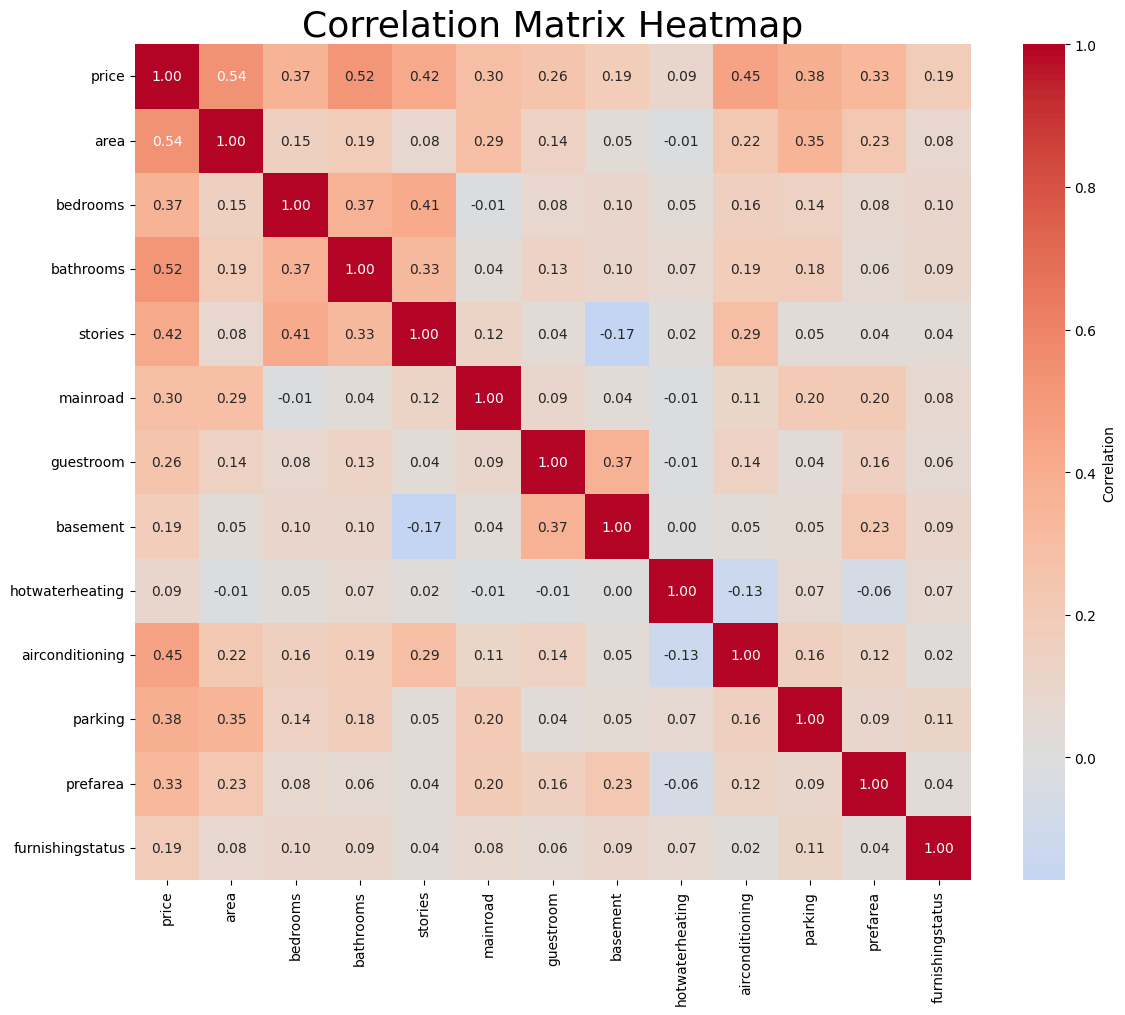

In [3]:
# Calculate correlation matrix
correlation_matrix = data.corr()
# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix Heatmap', fontsize=26)
plt.tight_layout()
plt.show()

### Correlation Matrix Analysis

The correlation matrix shows that none of the features are strongly correlated with each other (no pair exceeds ≈ 0.4). This indicates the absence of multicollinearity. As a result, the linear regression model should remain numerically stable and well-behaved without the need to drop features. 

The moderate correlations each feature has with the target (e.g., area, bathrooms, airconditioning) suggest that each variable contributes independently to explaining the price, allowing us to retain the full feature set in the model.

## Feature Analysis

In [5]:
data.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,1.089908
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.858130
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000


In [4]:
data.agg(["max", "min"])

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
max,13300000,16200,6,4,4,1,1,1,1,1,3,1,2
min,1750000,1650,1,1,1,0,0,0,0,0,0,0,0


### Feature Scale Analysis

From the summary statistics we can see that most features have small integer ranges, while `area` is the only one that covers a much larger range of values. When one feature has a scale much bigger than the others, it can end up influencing the optimization of a Linear Regression model more than it should. Therefore is safer to scale all numeric features (`area`, `bedrooms`, `bathrooms`, `stories`, `parking`) so that they contribute more evenly during training. 
The binary 0/1 features don’t need scaling.

### Treatment of the `furnishingstatus` Feature

The `furnishingstatus` column is encoded as 0, 1, and 2, but these numbers don’t really represent a linear or proportional relationship. The effect that furniture has on the final price depends on the market and isn’t necessarily “twice as important” when going from 1 to 2 compared to going from 0 to 1. This is also reflected in its low correlation with the target (around 0.19). For this reason, it may be better to treat it as a categorical variable and apply One-Hot Encoding. 
To verify this thesis, we will train two separate models: one using the numeric encoding (0, 1, 2) and one using One-Hot Encoding. This will allow us to directly compare their performance and see which approach works best for this dataset.